# Import Libraries

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
from keras.preprocessing import image 

# Define dataset parameters


In [12]:
image_height = 224
image_width = 224
num_channels = 3
batch_size = 32
num_classes = 3

# Get Image From each Directory ( Visualization)


In [13]:
data_path=r'bird-drone-hermes-data'
image_classes = os.listdir(data_path)
print(image_classes)

['bird', 'drone', 'hermes']


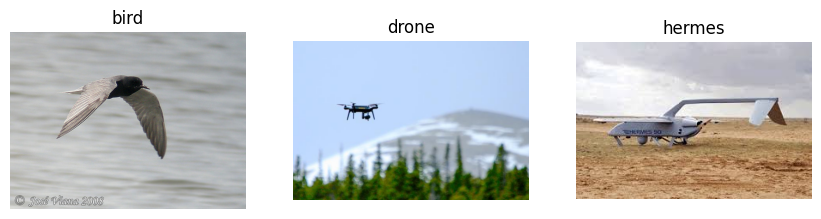

In [14]:
def plot_image(image_classes):
    plt.figure(figsize=(14 , 14))
    
    for i , category in enumerate(image_classes):
        image_path = data_path + '/' + category
        images_in_folder = os.listdir(image_path)
        
        first_image = images_in_folder[0]
        first_image_path = image_path + '/' + first_image 
        
        img= image.load_img(first_image_path)
        img_array = image.img_to_array(img) / 255
        
        plt.subplot(4 , 4 , i+1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')
    plt.show()
plot_image(image_classes)

In [15]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Split for training and validation
)

# Preprocessing Data & Split Data into Train & Test


In [16]:
train_data = train_datagen.flow_from_directory(
    r'bird-drone-hermes-data',  
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='sparse',
    subset='training'
)

Found 909 images belonging to 3 classes.


In [17]:
val_data = train_datagen.flow_from_directory(
    r'bird-drone-hermes-data',  
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation'
)

Found 227 images belonging to 3 classes.


# Load the pre-trained MobileNetV2 model


In [27]:
# base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(image_height, image_width, num_channels))

base_model = MobileNetV2(
    weights=None,  
    include_top=False,
    input_shape=(image_height, image_width, num_channels)
)

base_model.load_weights(r'mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5')

In [28]:
#Freeze the base model's layers to retain pre-trained weights
base_model.trainable = False

# Build the model

In [29]:
model = Sequential([
    base_model,  # Add the pre-trained model as the base
    GlobalAveragePooling2D(),  # Add a pooling layer
    Dense(128, activation='relu'),  # Fully connected layer
    Dropout(0.3),  # Dropout for regularization
    Dense(num_classes, activation='softmax')  # Output layer
])

# Compile the Model


In [30]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks

In [31]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

# Train the Model


In [32]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stopping, lr_scheduler, model_checkpoint]
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7360 - loss: 0.6789 - val_accuracy: 0.8899 - val_loss: 0.2888 - learning_rate: 0.0010
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 781ms/step - accuracy: 0.8867 - loss: 0.3136 - val_accuracy: 0.9207 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 739ms/step - accuracy: 0.8944 - loss: 0.2778 - val_accuracy: 0.9075 - val_loss: 0.2571 - learning_rate: 0.0010
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 22s 764ms/step - accuracy: 0.9131 - loss: 0.2292 - val_accuracy: 0.9075 - val_loss: 0.2063 - learning_rate: 0.0010
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 915ms/step - accuracy: 0.9307 - loss: 0.2134 - val_accuracy: 0.9471 - val_loss: 0.1604 - learning_rate: 0.0010
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9362 - loss: 0.1927 - val_accuracy: 0.9251 - val_loss: 0.2333 - learning_rate: 0.0010
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 990ms/step - accuracy: 0.9395 - loss: 0.1676 -

# Evaluate The Model Accuracy & Visualize Results

In [33]:
val_loss, val_accuracy = model.evaluate(val_data)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 455ms/step - accuracy: 0.9339 - loss: 0.1755
Validation Loss: 0.17549985647201538
Validation Accuracy: 0.933920681476593


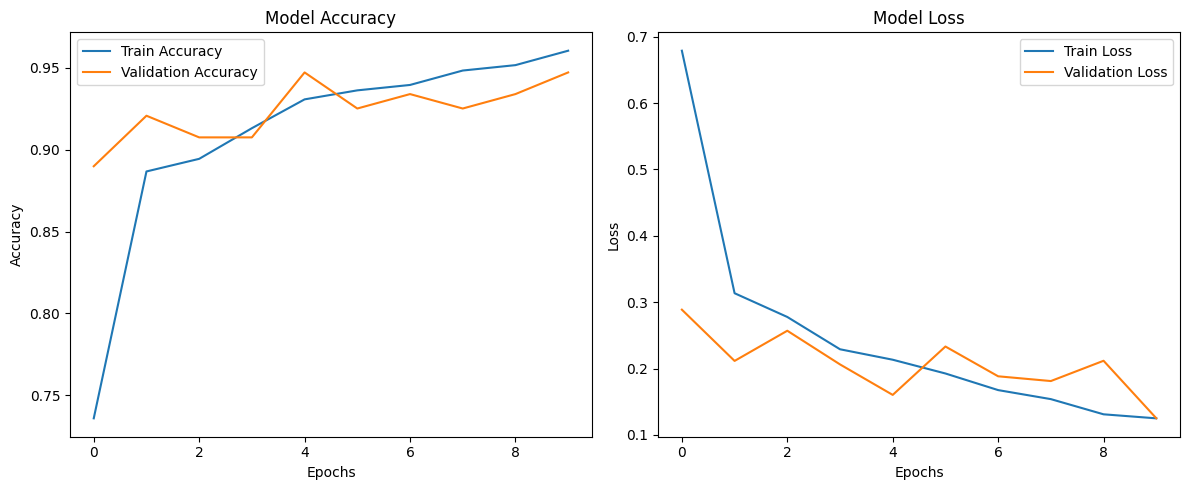

In [34]:
def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

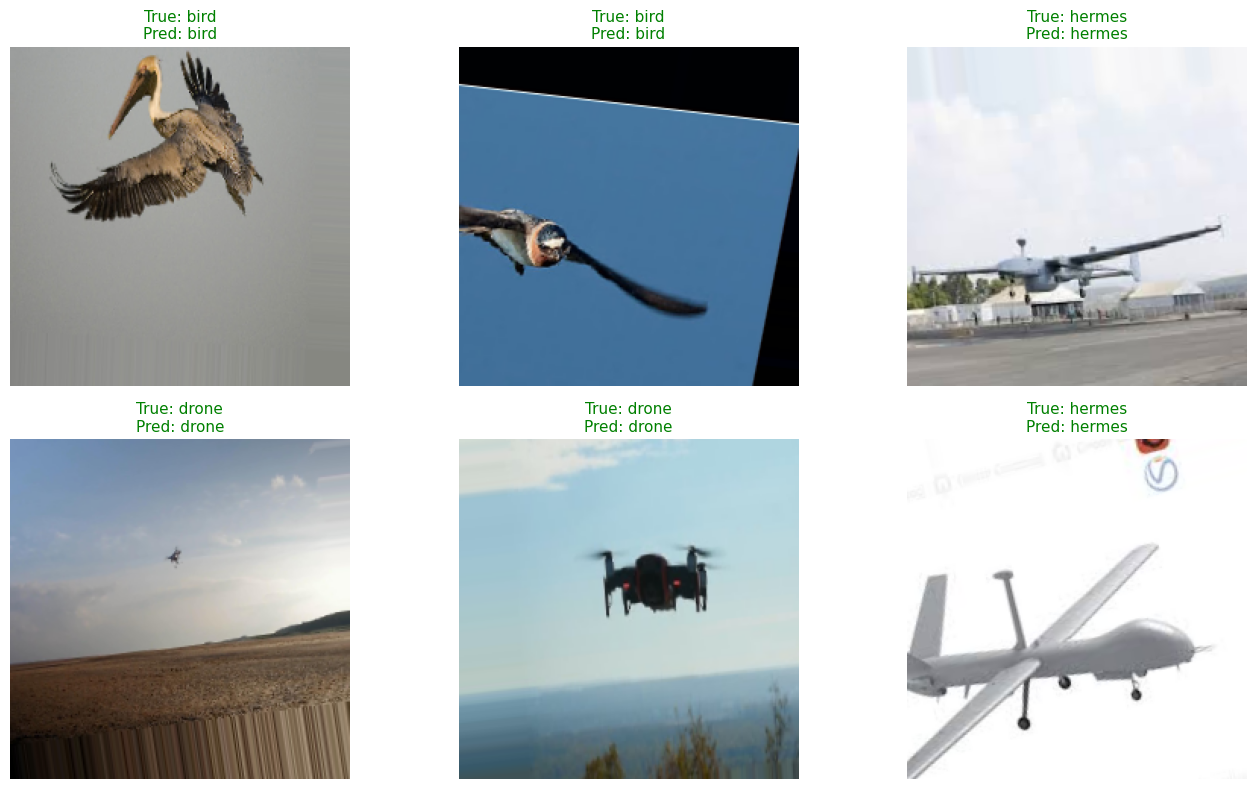

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def show_sample_predictions(model, data_gen, n_samples=6):
    images, labels = next(data_gen)  # images: (B, H, W, C), labels: (B,)
    preds = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    class_indices = data_gen.class_indices  
    idx_to_class = {v: k for k, v in class_indices.items()}

    n = min(n_samples, images.shape[0])

    plt.figure(figsize=(14, 8))
    for i in range(n):
        ax = plt.subplot(2, 3, i + 1)
        img = images[i]

        plt.imshow(img)
        ax.axis("off")

        true_idx = int(labels[i])
        pred_idx = int(pred_labels[i])
        true_name = idx_to_class[true_idx]
        pred_name = idx_to_class[pred_idx]

        correct = (true_idx == pred_idx)
        color = "green" if correct else "red"
        title = f"True: {true_name}\nPred: {pred_name}"
        ax.set_title(title, color=color, fontsize=11)

    plt.tight_layout()
    plt.show()

show_sample_predictions(model, val_data, n_samples=6)


# Save Model as h5

In [35]:
# Save the final trained model
# model.save("Drone vs Bird.h5")
